<a href="https://colab.research.google.com/github/mickeyob/mickeyob/blob/main/FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [90]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [91]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

In [92]:
class_names = train_data.classes

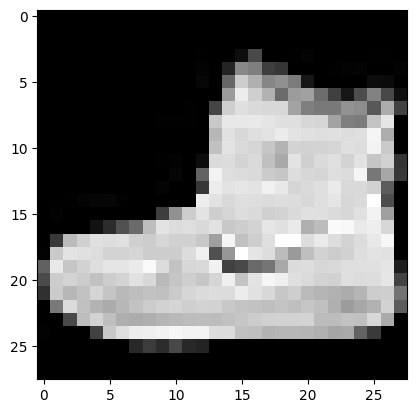

In [93]:
plt.imshow(train_data.data[0], cmap="gray")
plt.show()

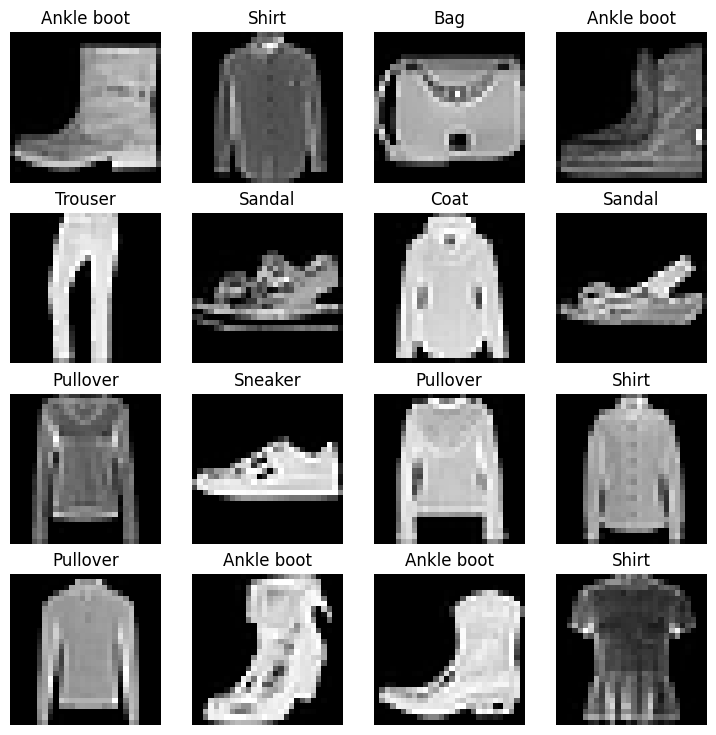

In [94]:
torch.manual_seed(42)

fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(class_names[label])
    plt.axis(False)

In [95]:
train_data_loader = DataLoader(train_data,
                               batch_size=32,
                               shuffle=True)
test_data_loader = DataLoader(test_data,
                              batch_size=32,
                              shuffle=False)

A function to calculate the training time of a model on a device (GPU or cpu)

In [96]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

Creating the baseline model with linear layers, with no activation functions


In [97]:
class BaseLineModel(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )
  def forward(self, x):
    return self.layer_stack(x)


In [98]:
torch.manual_seed(42)
model_0 = BaseLineModel(input_shape=784,
                        hidden_units=10,
                        output_shape=len(class_names))

In [99]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [100]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

Creating a function for the training step

In [101]:
# torch.manual_seed(42)
def train_step(model,
               optimizer,
               loss,
               accuracy,
               data_loader):
  model.train()
  train_loss = 0
  train_acc = 0
  for batch, (X,y) in enumerate(data_loader):
    model.to(device)
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    cost = loss(y_pred, y)
    train_loss += cost.item()
    train_acc += accuracy(y_true=y, y_pred=y_pred.argmax(dim=1))
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()
  print(f"Train loss: {train_loss/len(data_loader)} | Train accuracy: {train_acc/len(data_loader)}")


Creating a function for evaluation

In [102]:
torch.manual_seed(42)
def eval_step(model,
              loss,
              accuracy,
              data_loader):
  model.to(device)
  model.eval()
  test_loss = 0
  test_acc = 0
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      y_pred = model(X)
      test_loss += loss(y_pred, y).item()
      test_acc += accuracy(y_true=y, y_pred=y_pred.argmax(dim=1))
    print(f"Test loss: {test_loss/len(data_loader):.5f} | Test accuracy: {test_acc/len(data_loader):.5f}")

Training the Baseline model with 3 epochs

In [103]:
from tqdm.auto import tqdm
epochs = 4
model0_train_time_start = timer()
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")
  train_step(model=model_0,
             optimizer=optimizer,
             loss=loss_fn,
             accuracy=accuracy_fn,
             data_loader = train_data_loader)
  eval_step(model=model_0,
            loss=loss_fn,
            accuracy=accuracy_fn,
            data_loader=test_data_loader)
model0_train_timme_end = timer()
total_train_time_model_0 = print_train_time(start=model0_train_time_start, end=model0_train_timme_end, device=device)


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.635496274848779 | Train accuracy: 77.11333333333333
Test loss: 0.53045 | Test accuracy: 80.79073
Epoch: 1
---------
Train loss: 0.49990976924498876 | Train accuracy: 82.39166666666667
Test loss: 0.49107 | Test accuracy: 82.62780
Epoch: 2
---------
Train loss: 0.4741332427620888 | Train accuracy: 83.27666666666667
Test loss: 0.49889 | Test accuracy: 82.85743
Epoch: 3
---------
Train loss: 0.45985033858617147 | Train accuracy: 83.9
Test loss: 0.47949 | Test accuracy: 83.12700
Train time on cpu: 48.500 seconds


In [104]:
len(train_data_loader)

1875

Lets create a non-linear model with ReLU activation function and compare it with the baseline model

In [105]:
class NonLinearModel(nn.Module):
  def __init__(self, input_dim, hidden_dim, output_dim):
    super().__init__()
    self.stack_layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_dim, out_features=hidden_dim),
        nn.ReLU(),
        nn.Linear(in_features=hidden_dim, out_features=hidden_dim),
        nn.ReLU(),
        nn.Linear(in_features=hidden_dim, out_features=output_dim),
        nn.ReLU()
    )
  def forward(self, X):
    return self.stack_layer(X)

In [106]:
# torch.manual_seed(42)
model_1 = NonLinearModel(input_dim=784,
                         hidden_dim=10,
                         output_dim=len(class_names))

In [107]:
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

Let's train the non_linear model with 3 epochs

In [108]:
torch.manual_seed(42)
epochs = 4
model1_train_time_start = timer()
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")
  train_step(model=model_1,
             optimizer=optimizer,
             loss=loss_fn,
             accuracy=accuracy_fn,
             data_loader = train_data_loader)
  eval_step(model=model_1,
            loss=loss_fn,
            accuracy=accuracy_fn,
            data_loader=test_data_loader,
            )
model1_train_time_end = timer()
total_train_time_model_1 = print_train_time(start=model1_train_time_start, end=model1_train_time_end, device=device)


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 1.0241755069573721 | Train accuracy: 66.74166666666666
Test loss: 0.72482 | Test accuracy: 78.22484
Epoch: 1
---------
Train loss: 0.6616634734312693 | Train accuracy: 79.60666666666667
Test loss: 0.54746 | Test accuracy: 80.61102
Epoch: 2
---------
Train loss: 0.47488606282075246 | Train accuracy: 83.165
Test loss: 0.47399 | Test accuracy: 83.45647
Epoch: 3
---------
Train loss: 0.4424429584503174 | Train accuracy: 84.01
Test loss: 0.45681 | Test accuracy: 83.71605
Train time on cpu: 49.804 seconds


In [109]:
def results(model,
            data_loader,
            loss,
            accuracy):
  model.eval()
  cost = 0
  acc = 0
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      y_pred = model(X)
      cost += loss(y_pred, y)
      acc += accuracy(y_true=y, y_pred=y_pred.argmax(dim=1))
    cost /= len(data_loader)
    acc /= len(data_loader)
  return {"Model": model.__class__.__name__,
          "Test loss": cost.item(),
          "Test accuracy": acc}

In [110]:
model_0_results = results(model=model_0,
                          data_loader=test_data_loader,
                          loss=loss_fn,
                          accuracy=accuracy_fn)

In [111]:
model_0_results

{'Model': 'BaseLineModel',
 'Test loss': 0.47948795557022095,
 'Test accuracy': 83.12699680511182}

In [112]:
model_1_results = results(model=model_1,
                          data_loader=test_data_loader,
                          loss=loss_fn,
                          accuracy=accuracy_fn)
model_1_results

{'Model': 'NonLinearModel',
 'Test loss': 0.45680612325668335,
 'Test accuracy': 83.71605431309904}

Let's create a Tiny VGG Architecture using CNN and compare its results with the other models.


In [113]:
class TinyVGG(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                      stride=2)
    )
    self.conv_block2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                      stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*4*4,
                  out_features=output_shape)
    )
  def forward(self, x):
    x = self.conv_block_1(x)
    x = self.conv_block2(x)
    x = self.classifier(x)
    return x

In [114]:
model_2 = TinyVGG(input_shape=1,
                   hidden_units=10,
                   output_shape=len(class_names)).to(device)

In [115]:
random_tensor = torch.randn(size = (32, 1, 28,28)).to(device)
random_tensor.shape

torch.Size([32, 1, 28, 28])

In [116]:
model_2(random_tensor).shape

torch.Size([32, 10])

Let's train the Tiny VGG model

In [117]:
epochs = 4
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)
model2_train_time_start = timer()
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")
  train_step(model=model_2,
             optimizer=optimizer,
             loss=loss_fn,
             accuracy=accuracy_fn,
             data_loader = train_data_loader)
  eval_step(model=model_2,
            loss=loss_fn,
            accuracy=accuracy_fn,
            data_loader=test_data_loader,
            )
model2_train_time_end = timer()
total_train_time_model_2 = print_train_time(start=model2_train_time_start, end=model2_train_time_end, device=device)


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.7571782725890478 | Train accuracy: 72.13
Test loss: 0.55426 | Test accuracy: 79.53275
Epoch: 1
---------
Train loss: 0.4821435020128886 | Train accuracy: 82.68666666666667
Test loss: 0.47298 | Test accuracy: 83.10703
Epoch: 2
---------
Train loss: 0.43254477303028105 | Train accuracy: 84.47833333333334
Test loss: 0.43123 | Test accuracy: 84.86422
Epoch: 3
---------
Train loss: 0.4016185117562612 | Train accuracy: 85.49666666666667
Test loss: 0.39129 | Test accuracy: 85.71286
Train time on cpu: 201.388 seconds


In [118]:
X = train_data.data
X.shape

torch.Size([60000, 28, 28])

In [119]:
model_2_results = results(model=model_2,
                          data_loader=test_data_loader,
                          loss=loss_fn,
                          accuracy=accuracy_fn)
model_2_results

{'Model': 'TinyVGG',
 'Test loss': 0.3912945091724396,
 'Test accuracy': 85.71285942492013}

In [120]:
model_0_results

{'Model': 'BaseLineModel',
 'Test loss': 0.47948795557022095,
 'Test accuracy': 83.12699680511182}

In [121]:
model_1_results

{'Model': 'NonLinearModel',
 'Test loss': 0.45680612325668335,
 'Test accuracy': 83.71605431309904}

Comparing the results of our modelling experiments

In [122]:
import pandas as pd
compare_results = pd.DataFrame(data=[model_0_results, model_1_results, model_2_results])
compare_results

,Model,Test loss,Test accuracy
0,BaseLineModel,0.479488,83.126997
1,NonLinearModel,0.456806,83.716054
2,TinyVGG,0.391295,85.712859


In [123]:
compare_results["Training time"] = [total_train_time_model_0, total_train_time_model_1, total_train_time_model_2]
compare_results

,Model,Test loss,Test accuracy,Training time
0,BaseLineModel,0.479488,83.126997,48.500330
1,NonLinearModel,0.456806,83.716054,49.803851
2,TinyVGG,0.391295,85.712859,201.388337


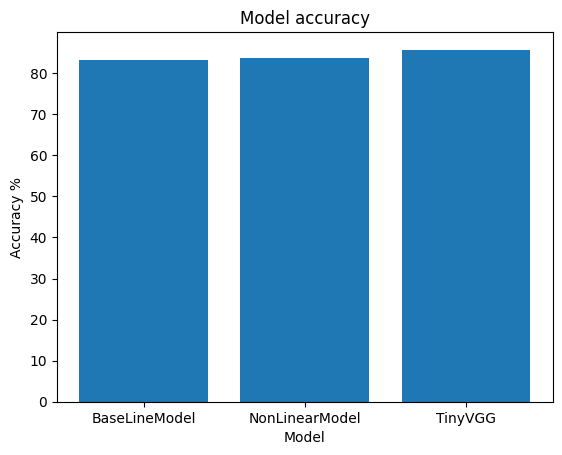

In [124]:
plt.bar(x=compare_results["Model"], height=compare_results["Test accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy %")
plt.title("Model accuracy")
plt.show()

Making predictions on random test samples with the best trained model

In [125]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())

    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [126]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


In [127]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


In [128]:
# Make predictions on test samples with model 2
pred_probs= make_predictions(model=model_2,
                             data=test_samples)

# View first two prediction probabilities list
pred_probs[:2]

tensor([[1.2992e-06, 5.7413e-07, 1.0176e-07, 4.7788e-06, 1.3732e-06, 9.7083e-01,
         4.5555e-06, 5.0662e-05, 2.0395e-04, 2.8905e-02],
        [2.6990e-03, 9.7981e-01, 2.6076e-04, 1.1024e-02, 2.6247e-03, 1.6091e-06,
         9.8301e-04, 2.9684e-06, 2.5933e-03, 4.2100e-07]])

In [129]:
# Turn the prediction probabilities into prediction labels by taking the argmax()
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

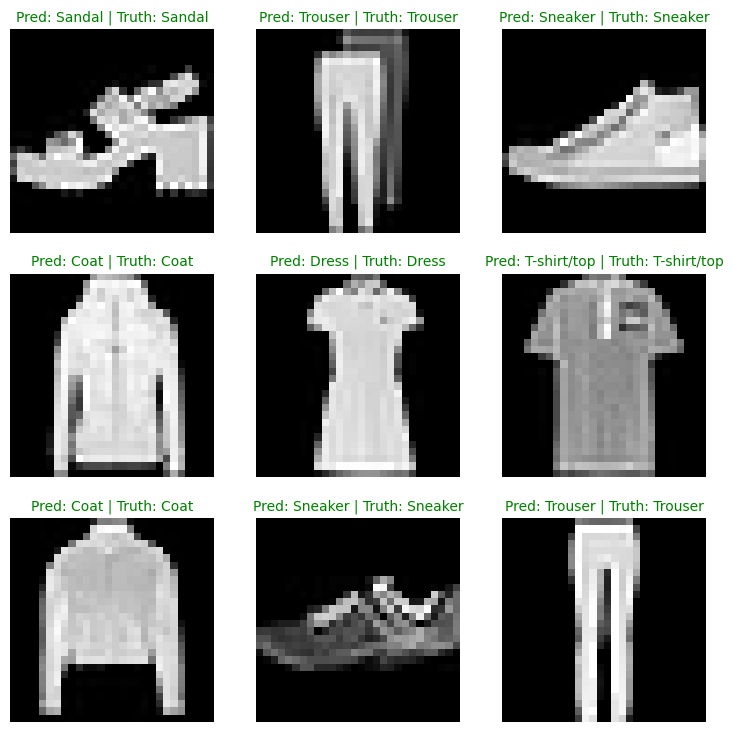

In [130]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]]

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);